# Chapter 5 Companion — Quantum Error Correction

Runnable companions to the worked examples in
[`docs/05_quantum_error_correction`](../docs/05_quantum_error_correction):

- [`03_repetition_code.md`](../docs/05_quantum_error_correction/03_repetition_code.md)
- [`05_css_codes_and_steane.md`](../docs/05_quantum_error_correction/05_css_codes_and_steane.md)
- [`06_surface_code.md`](../docs/05_quantum_error_correction/06_surface_code.md)

Syndromes are computed over **GF(2)**: a Z-type stabilizer with support `h` anticommutes with
an X-error of support `e` iff `⟨h, e⟩ = 1 (mod 2)` — so the whole syndrome extraction is a
binary matrix-vector product.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

def gf2_syndrome(check_matrix, error_support):
    '''Binary syndrome bits: 1 = anticommutes (eigenvalue -1).'''
    return (check_matrix @ error_support) % 2

## Example 1 — 3-qubit bit-flip code: syndrome table, and how two flips fool it

*Docs: `03_repetition_code.md`.* Stabilizers `Z₁Z₂, Z₂Z₃`. Each single X error has a unique
syndrome (table in the docs). Exercise 3 shows the failure mode: the two-flip error `X₁X₂`
produces the syndrome of `X₃`, so the decoder "corrects" with `X₃` and completes the logical
`X_L = X₁X₂X₃`. We verify both with GF(2) syndromes and with a full statevector simulation.

In [2]:
# Z-type checks (rows = stabilizer supports over the 3 qubits)
Hz = np.array([[1, 1, 0],    # Z1 Z2
               [0, 1, 1]])   # Z2 Z3

single_errors = {"none": [0,0,0], "X1": [1,0,0], "X2": [0,1,0], "X3": [0,0,1]}
print("error  syndrome (Z1Z2, Z2Z3)   [docs table: none=(+,+), X1=(-,+), X2=(-,-), X3=(+,-)]")
table = {}
for name, e in single_errors.items():
    s = tuple(gf2_syndrome(Hz, np.array(e)))
    table[s] = np.array(e)
    print(f"{name:5s}  {s}")
assert len(table) == 4          # all four syndromes distinct -> weight-1 errors correctable

# Exercise 3: the double error X1 X2
e2 = np.array([1, 1, 0])
s2 = tuple(gf2_syndrome(Hz, e2))
correction = table[s2]
net = (e2 + correction) % 2
print(f"\nX1X2 syndrome = {s2} -> decoder applies X on qubit {np.argmax(correction)+1}")
print("net operator support:", net, "= X1X2X3 = logical X ->", np.array_equal(net, [1,1,1]))
assert np.array_equal(net, [1, 1, 1])

# Statevector confirmation: encode a|000>+b|111>, hit with X1X2, decode, get logical flip
a, b = 0.6, 0.8
psi = np.zeros(8); psi[0b000] = a; psi[0b111] = b     # index bit order: q1 q2 q3
def apply_X(psi, qubit):   # qubit in {1,2,3}, big-endian labels as in the docs
    out = np.zeros_like(psi)
    for idx in range(8):
        out[idx ^ (1 << (3 - qubit))] = psi[idx]
    return out
damaged = apply_X(apply_X(psi, 1), 2)
decoded = apply_X(damaged, np.argmax(correction) + 1)
print("decoded state amplitudes at |000>,|111>:", decoded[0], decoded[7],
      "-> logical X applied (a<->b):", np.isclose(decoded[0], b) and np.isclose(decoded[7], a))
assert np.isclose(decoded[0], b) and np.isclose(decoded[7], a)

error  syndrome (Z1Z2, Z2Z3)   [docs table: none=(+,+), X1=(-,+), X2=(-,-), X3=(+,-)]
none   (np.int64(0), np.int64(0))
X1     (np.int64(1), np.int64(0))
X2     (np.int64(1), np.int64(1))
X3     (np.int64(0), np.int64(1))

X1X2 syndrome = (np.int64(0), np.int64(1)) -> decoder applies X on qubit 3
net operator support: [1 1 1] = X1X2X3 = logical X -> True
decoded state amplitudes at |000>,|111>: 0.8 0.6 -> logical X applied (a<->b): True


## Example 2 — Shor `[[9,1,3]]` code: syndromes of `Y₄` and the impostor `X₁X₄X₇`

*Docs: `03_repetition_code.md`.* The worked example: a `Y₄` error (both X and Z on qubit 4).
Its X-component trips the block-2 Z-checks `(Z₄Z₅, Z₅Z₆) = (−1,+1)`; its Z-component trips
both X-type checks `(−1,−1)`, identifying block 2. Exercise 1: `X₁X₄X₇` is **not** a logical
operator — it anticommutes with `Z₁Z₂, Z₄Z₅, Z₇Z₈`, producing syndrome
`(-1,+1,-1,+1,-1,+1,+1,+1)`.

In [3]:
q = lambda *idx: np.array([1 if i+1 in idx else 0 for i in range(9)])

# Z-type stabilizer supports (detect X errors); X-type supports (detect Z errors)
Z_checks = [("Z1Z2", q(1,2)), ("Z2Z3", q(2,3)), ("Z4Z5", q(4,5)),
            ("Z5Z6", q(5,6)), ("Z7Z8", q(7,8)), ("Z8Z9", q(8,9))]
X_checks = [("X1..X6", q(1,2,3,4,5,6)), ("X4..X9", q(4,5,6,7,8,9))]

def full_syndrome(x_support, z_support):
    sZ = [int(h @ x_support % 2) for _, h in Z_checks]   # Z-checks see X errors
    sX = [int(h @ z_support % 2) for _, h in X_checks]   # X-checks see Z errors
    return sZ + sX

# Y4 = X4 * Z4 (up to phase)
sy = full_syndrome(q(4), q(4))
names = [n for n, _ in Z_checks] + [n for n, _ in X_checks]
print("Y4 syndrome:", dict(zip(names, sy)))
assert sy == [0, 0, 1, 0, 0, 0, 1, 1]     # (Z4Z5)=-1, both X-checks=-1 -> block 2, qubit 4
print("-> X-part localized to qubit 4 (Z4Z5=-1, Z5Z6=+1); Z-part localized to block 2 ✓")

# Exercise 1: X1X4X7
s_imp = full_syndrome(q(1, 4, 7), np.zeros(9, dtype=int))
print("\nX1X4X7 syndrome:", dict(zip(names, s_imp)))
assert s_imp == [1, 0, 1, 0, 1, 0, 0, 0]  # docs: (-1,+1,-1,+1,-1,+1,+1,+1)
print("-> nonzero syndrome: a detectable weight-3 error, NOT a logical operator ✓")

# True logical operators commute with everything: Xbar = Z1Z4Z7, Zbar = X1X2X3
assert full_syndrome(np.zeros(9,dtype=int), q(1,4,7)) == [0]*8    # Z1Z4Z7
assert full_syndrome(q(1,2,3), np.zeros(9,dtype=int)) == [0]*8    # X1X2X3
print("Z1Z4Z7 and X1X2X3 have trivial syndrome -> valid logical X̄ and Z̄ ✓")

Y4 syndrome: {'Z1Z2': 0, 'Z2Z3': 0, 'Z4Z5': 1, 'Z5Z6': 0, 'Z7Z8': 0, 'Z8Z9': 0, 'X1..X6': 1, 'X4..X9': 1}
-> X-part localized to qubit 4 (Z4Z5=-1, Z5Z6=+1); Z-part localized to block 2 ✓

X1X4X7 syndrome: {'Z1Z2': 1, 'Z2Z3': 0, 'Z4Z5': 1, 'Z5Z6': 0, 'Z7Z8': 1, 'Z8Z9': 0, 'X1..X6': 0, 'X4..X9': 0}
-> nonzero syndrome: a detectable weight-3 error, NOT a logical operator ✓
Z1Z4Z7 and X1X2X3 have trivial syndrome -> valid logical X̄ and Z̄ ✓


## Example 3 — Steane `[[7,1,3]]` code: GF(2) machinery of the Hamming matrix

*Docs: `05_css_codes_and_steane.md`.* Everything flows from the `[7,4,3]` Hamming parity-check
matrix `H` (columns = binary 1…7):

- `H Hᵀ = 0 (mod 2)` — proves `C⊥ ⊆ C` **and** that all X/Z stabilizers commute (Exercise 1).
- A `Z₃` error trips X-checks by column 3 of `H`: syndrome `011₂ = 3` (worked example).
- An `X₆` error: syndrome `110₂ = 6` (Exercise 3).
- `1110000` is a Hamming codeword of odd weight ⟹ `X₁X₂X₃`/`Z₁Z₂Z₃` are weight-3 logical
  operators (Exercise 2).

In [4]:
Hmat = np.array([[0,0,0,1,1,1,1],
                 [0,1,1,0,0,1,1],
                 [1,0,1,0,1,0,1]])

print("H Hᵀ mod 2 =\n", (Hmat @ Hmat.T) % 2, " -> C⊥ ⊆ C and all stabilizers commute")
assert np.all((Hmat @ Hmat.T) % 2 == 0)

def steane_syndrome(err_support):
    '''3-bit syndrome (s1,s2,s3), read as binary = error position (Hamming decoding).'''
    s = (Hmat @ err_support) % 2
    return s, int("".join(map(str, s)), 2)

for pos, kind in [(3, "Z"), (6, "X")]:
    e = np.zeros(7, dtype=int); e[pos-1] = 1
    s, loc = steane_syndrome(e)
    print(f"{kind}{pos} error -> syndrome {tuple(s)} = {loc}  (decoder applies {kind}{loc})")
    assert loc == pos
print("Hamming structure: the syndrome *is* the binary error position ✓")

# every single-qubit error position decodes correctly
assert all(steane_syndrome(np.eye(7, dtype=int)[p])[1] == p + 1 for p in range(7))

# logical operators: support 1110000
v = np.array([1,1,1,0,0,0,0])
print("\nH·(1110000)ᵀ mod 2 =", (Hmat @ v) % 2, " -> a Hamming codeword (commutes with all checks)")
assert np.all((Hmat @ v) % 2 == 0)
print("weight =", v.sum(), "(odd) -> in C \\ C⊥: X1X2X3 / Z1Z2Z3 are weight-3 logicals;")
overlap = (v @ v) % 2
print("X̄ and Z̄ share", v.sum(), "positions (odd) -> they anticommute ✓")

# codeword weights: C⊥ has weights {0,4}; the logical coset C \ C⊥ has weights {3,7}
from itertools import product
codewords = [np.array(c) for c in product([0,1], repeat=7) if np.all((Hmat @ np.array(c)) % 2 == 0)]
# C⊥ = row space of H (the simplex code): all GF(2) combinations of the 3 rows
dual = {tuple((a*Hmat[0] + b*Hmat[1] + c*Hmat[2]) % 2)
        for a, b, c in product([0, 1], repeat=3)}
w_dual = sorted(sum(c) for c in dual)
w_coset = sorted(int(c.sum()) for c in codewords if tuple(c) not in dual)
print("\n|C| =", len(codewords), " C⊥ weights:", set(w_dual), " logical-coset weights:", set(w_coset))
assert set(w_dual) == {0, 4} and set(w_coset) == {3, 7}
assert all(tuple(d) in {tuple(c) for c in codewords} for d in dual)   # C⊥ ⊆ C, again

H Hᵀ mod 2 =
 [[0 0 0]
 [0 0 0]
 [0 0 0]]  -> C⊥ ⊆ C and all stabilizers commute
Z3 error -> syndrome (np.int64(0), np.int64(1), np.int64(1)) = 3  (decoder applies Z3)
X6 error -> syndrome (np.int64(1), np.int64(1), np.int64(0)) = 6  (decoder applies X6)
Hamming structure: the syndrome *is* the binary error position ✓

H·(1110000)ᵀ mod 2 = [0 0 0]  -> a Hamming codeword (commutes with all checks)
weight = 3 (odd) -> in C \ C⊥: X1X2X3 / Z1Z2Z3 are weight-3 logicals;
X̄ and Z̄ share 3 positions (odd) -> they anticommute ✓

|C| = 16  C⊥ weights: {np.int64(0), np.int64(4)}  logical-coset weights: {3, 7}


## Example 4 — Surface-code logical error rate: `p_L ≈ 0.1 (p/p_th)^{⌈d/2⌉}`

*Docs: `06_surface_code.md`, "Resource Estimates".* Below threshold, distance buys
exponential suppression. At `p = 10⁻³`, `p_th = 10⁻²` the docs tabulate `p_L` from `~10⁻³`
(d=3) down to `~10⁻¹⁴` (d=25), and Exercise 4 finds `d = 27` for `p_L ≤ 10⁻¹⁵`
(1457 physical qubits). We reproduce the table and plot `p_L(p)` for several `d`, showing all
curves crossing at `p = p_th` — the threshold behaviour.

  d data qubits d^2  p_L at p=1e-3   (docs table)
  3               9          1e-03   1e-03
  5              25          1e-04   1e-04
  7              49          1e-05   1e-05
 11             121          1e-07   1e-07
 17             289          1e-10   1e-10
 21             441          1e-12   1e-12
 25             625          1e-14   1e-14

smallest odd d with p_L <= 1e-15: d = 27 (729 data + 728 ancilla = 1457 physical qubits)  (docs: 27, 1457)


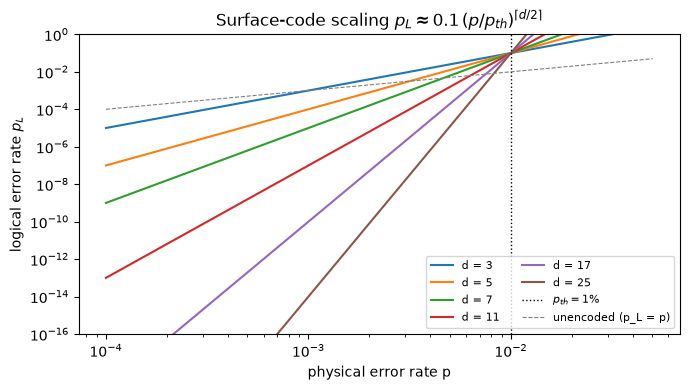

below threshold larger d helps exponentially; above threshold it makes things worse.


In [5]:
p_th = 1e-2

def p_L(p, d, A=0.1):
    return A * (p / p_th)**np.ceil(d / 2)

print(f"{'d':>3} {'data qubits d^2':>15} {'p_L at p=1e-3':>14}   (docs table)")
doc_pl = {3: 1e-3, 5: 1e-4, 7: 1e-5, 11: 1e-7, 17: 1e-10, 21: 1e-12, 25: 1e-14}
for d, expected in doc_pl.items():
    val = p_L(1e-3, d)
    print(f"{d:>3} {d*d:>15} {val:>14.0e}   {expected:.0e}")
    assert np.isclose(val, expected)

# Exercise 4: smallest odd d with p_L <= 1e-15 (tiny float tolerance: 0.1*0.1^14 = 1e-15)
d = next(d for d in range(3, 100, 2) if p_L(1e-3, d) <= 1e-15 * (1 + 1e-9))
print(f"\nsmallest odd d with p_L <= 1e-15: d = {d} "
      f"({d*d} data + {d*d-1} ancilla = {2*d*d-1} physical qubits)  (docs: 27, 1457)")
assert d == 27 and 2*d*d - 1 == 1457

ps = np.logspace(-4, -1.3, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for d in (3, 5, 7, 11, 17, 25):
    ax.loglog(ps, p_L(ps, d), label=f"d = {d}")
ax.axvline(p_th, color="k", ls=":", lw=1, label=r"$p_{th} = 1\%$")
ax.loglog(ps, ps, color="gray", lw=0.8, ls="--", label="unencoded (p_L = p)")
ax.set_xlabel("physical error rate p"); ax.set_ylabel(r"logical error rate $p_L$")
ax.set_ylim(1e-16, 1)
ax.set_title(r"Surface-code scaling $p_L \approx 0.1\,(p/p_{th})^{\lceil d/2\rceil}$")
ax.legend(fontsize=8, ncol=2); fig.tight_layout(); plt.show()
print("below threshold larger d helps exponentially; above threshold it makes things worse.")

## Example 5 — Repetition-code logical failure vs. physical error rate (Monte Carlo)

*Docs: `03_repetition_code.md`, "Bit-Flip Error Model".* Under independent bit flips with
probability `p`, the 3-qubit code fails when ≥2 qubits flip:
`p_fail = 3p²(1−p) + p³ ≈ 3p²`. Monte-Carlo sampling of the code + majority-vote decoder
reproduces the closed form, and shows the pseudo-threshold `p_fail < p` for `p < 1/2`.

p = 0.005:  Monte-Carlo p_fail = 0.00007,  exact 3p²(1-p)+p³ = 0.00007
p = 0.010:  Monte-Carlo p_fail = 0.00030,  exact 3p²(1-p)+p³ = 0.00030
p = 0.020:  Monte-Carlo p_fail = 0.00112,  exact 3p²(1-p)+p³ = 0.00118
p = 0.050:  Monte-Carlo p_fail = 0.00708,  exact 3p²(1-p)+p³ = 0.00725
p = 0.100:  Monte-Carlo p_fail = 0.02836,  exact 3p²(1-p)+p³ = 0.02800
p = 0.200:  Monte-Carlo p_fail = 0.10565,  exact 3p²(1-p)+p³ = 0.10400
p = 0.300:  Monte-Carlo p_fail = 0.21702,  exact 3p²(1-p)+p³ = 0.21600


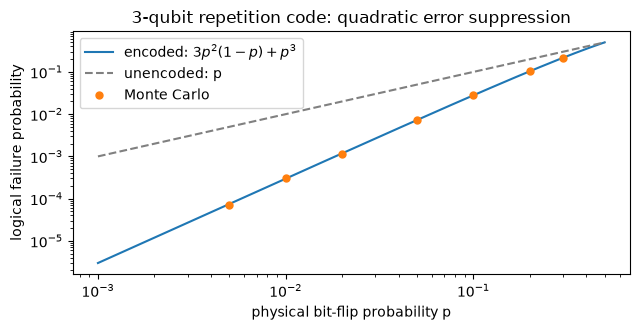

In [6]:
rng = np.random.default_rng(7)

def logical_failure_rate(p, trials=200_000):
    flips = rng.random((trials, 3)) < p
    n_flipped = flips.sum(axis=1)
    return np.mean(n_flipped >= 2)     # majority vote fails iff >= 2 flips

ps = np.array([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3])
mc = np.array([logical_failure_rate(p) for p in ps])
exact = 3*ps**2*(1-ps) + ps**3
for p, m, e in zip(ps, mc, exact):
    print(f"p = {p:5.3f}:  Monte-Carlo p_fail = {m:.5f},  exact 3p²(1-p)+p³ = {e:.5f}")
assert np.allclose(mc, exact, atol=3e-3)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
pp = np.linspace(1e-3, 0.5, 200)
ax.loglog(pp, 3*pp**2*(1-pp) + pp**3, label=r"encoded: $3p^2(1-p)+p^3$")
ax.loglog(pp, pp, "--", color="gray", label="unencoded: p")
ax.loglog(ps, mc, "o", ms=5, label="Monte Carlo")
ax.set_xlabel("physical bit-flip probability p"); ax.set_ylabel("logical failure probability")
ax.set_title("3-qubit repetition code: quadratic error suppression")
ax.legend(); fig.tight_layout(); plt.show()